# 🎮 Game Event Analysis — Churn & Revenue Report
**Audience:** Game Design Team

---

## This report answers:

| # | Question |
|---|----------|
| **1a** | Which missions are we losing the most players at? |
| **1b** | Does churn behavior differ by player level? *(10-level groups)* |
| **2a** | How much total revenue did the event generate? |
| **2b** | Which player levels generated the most money? |
| **3** | What can we change to improve future events? |

---

> **Churn:** A player "churns" when they start a mission but do not start the next one.  
> **Skip Revenue:** Players pay premium currency to skip missions. Revenue = skips × cost per skip × $0.0499/currency (100 gems = $4.99).

**Data:** One row per *(player level × mission)*. Covers player levels **2–41** across **5 chapters**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

# ── Consistent visual style across all charts ─────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "white"

# Color palette
PINK   = "#E8007D"
BLUE   = "#2563EB"
ORANGE = "#F97316"

# Per-chapter colors (used across all charts for consistency)
CHAPTER_COLORS = {1: "#E8007D", 2: "#F97316", 3: "#FACC15", 4: "#2563EB", 5: "#7C3AED"}
legend_handles = [
    Patch(color=CHAPTER_COLORS[c], label=f"Chapter {c}")
    for c in sorted(CHAPTER_COLORS)
]

In [2]:
# ── 1. Load raw Excel ─────────────────────────────────────────────
df_raw = pd.read_excel("Test Data analyst.xlsx", sheet_name=0)

# First data row is the actual column header
df = df_raw.copy()
df.columns = df_raw.iloc[0].tolist()
df = df.iloc[1:].reset_index(drop=True)

# ── 2. Rename to clean, Power-BI-safe names (no spaces) ──────────
df.columns = ["player_level", "mission_name", "users_start", "users_skipped", "skip_cost"]

# ── 3. Convert all columns to numeric ────────────────────────────
for col in ["player_level", "users_start", "users_skipped", "skip_cost"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ── 4. Parse chapter & mission numbers for correct ordering ───────
df["chapter_num"]    = df["mission_name"].str.extract(r"Chapter(\d+)").astype(int)
df["mission_num"]    = df["mission_name"].str.extract(r"mission(\d+)").astype(int)
df["mission_order"]  = df["chapter_num"] * 100 + df["mission_num"]   # global sort key

# ── 5. Player level groups of 10 ──────────────────────────────────
MAX_LEVEL           = int(df["player_level"].max())
df["lvl_grp_start"] = ((df["player_level"] - 2) // 10) * 10 + 2
df["lvl_grp_end"]   = (df["lvl_grp_start"] + 9).clip(upper=MAX_LEVEL)
df["level_group"]   = (
    "Lvl " + df["lvl_grp_start"].astype(int).astype(str)
    + "–"  + df["lvl_grp_end"].astype(int).astype(str)
)

# ── 6. Revenue: 100 premium currency = $4.99 ──────────────────────
USD_PER_CURRENCY  = 4.99 / 100
df["revenue_usd"] = df["users_skipped"] * df["skip_cost"] * USD_PER_CURRENCY
df["skip_rate"]   = df["users_skipped"] / df["users_start"]

# ── Summary ───────────────────────────────────────────────────────
print(f"✅ Loaded {len(df):,} rows")
print(f"   Player levels : {df['player_level'].min()} – {df['player_level'].max()}")
print(f"   Missions      : {df['mission_name'].nunique()} across {df['chapter_num'].nunique()} chapters")
print(f"   Level groups  : {sorted(df['level_group'].unique())}")
df.head()

✅ Loaded 2,040 rows
   Player levels : 2 – 41
   Missions      : 51 across 5 chapters
   Level groups  : ['Lvl 12–21', 'Lvl 22–31', 'Lvl 2–11', 'Lvl 32–41']


,player_level,mission_name,users_start,users_skipped,skip_cost,chapter_num,mission_num,mission_order,lvl_grp_start,lvl_grp_end,level_group,revenue_usd,skip_rate
0,2,Chapter1_mission1,423821,2668,15,1,1,101,2,11,Lvl 2–11,1996.9980,0.006295
1,2,Chapter1_mission2,225147,2599,15,1,2,102,2,11,Lvl 2–11,1945.3515,0.011544
2,2,Chapter1_mission3,130801,2829,15,1,3,103,2,11,Lvl 2–11,2117.5065,0.021628
3,2,Chapter1_mission4,59202,3657,15,1,4,104,2,11,Lvl 2–11,2737.2645,0.061772
4,2,Chapter1_mission5,27508,529,75,1,5,105,2,11,Lvl 2–11,1979.7825,0.019231


---
## 📉 Section 1 — Churn Analysis

> **How it works:** For each player level, we compare how many players started mission *N* vs. mission *N+1*.  
> The drop between them = players we lost at that step.  
> We then aggregate across all player levels to find which missions lose the most players overall.

In [3]:
# Sort by player level, then by correct mission order
df_s = df.sort_values(["player_level", "mission_order"]).reset_index(drop=True)

# Next mission's start count, grouped within each player level
df_s["next_start"] = df_s.groupby("player_level")["users_start"].shift(-1)

# Churn metrics
df_s["churn_players"] = (df_s["users_start"] - df_s["next_start"]).clip(lower=0)
df_s["churn_rate"]    = df_s["churn_players"] / df_s["users_start"]

# The last mission per level has no "next" — exclude from averages
df_s.loc[df_s["next_start"].isna(), ["churn_players", "churn_rate"]] = np.nan

print("✅ Churn computed — sample (player level 2):")
df_s[df_s["player_level"] == 2][
    ["mission_name", "users_start", "next_start", "churn_players", "churn_rate"]
].head(10)

✅ Churn computed — sample (player level 2):


,mission_name,users_start,next_start,churn_players,churn_rate
0,Chapter1_mission1,423821,225147.0,198674.0,0.468769
1,Chapter1_mission2,225147,130801.0,94346.0,0.419042
2,Chapter1_mission3,130801,59202.0,71599.0,0.547389
3,Chapter1_mission4,59202,27508.0,31694.0,0.535354
4,Chapter1_mission5,27508,15364.0,12144.0,0.441472
5,Chapter2_mission1,15364,13363.0,2001.0,0.130240
6,Chapter2_mission2,13363,11431.0,1932.0,0.144578
7,Chapter2_mission3,11431,8579.0,2852.0,0.249497
8,Chapter2_mission4,8579,4991.0,3588.0,0.418231
9,Chapter2_mission5,4991,3404.0,1587.0,0.317972


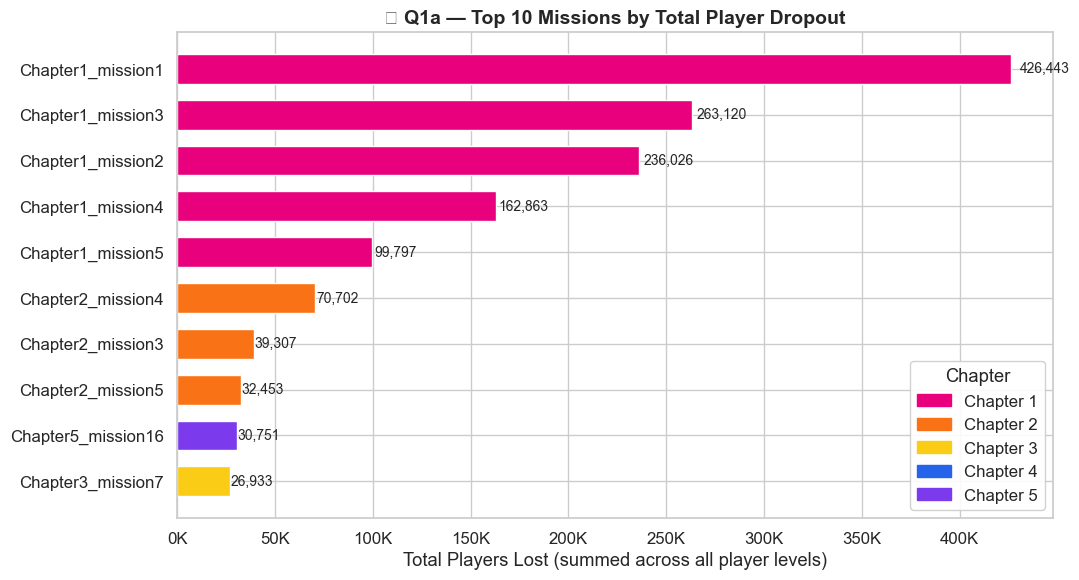

📊 Top 10 by absolute player loss:
      mission_name  players_lost churn_rate_%
 Chapter1_mission1      426443.0        25.6%
 Chapter1_mission3      263120.0        26.3%
 Chapter1_mission2      236026.0        19.1%
 Chapter1_mission4      162863.0        22.0%
 Chapter1_mission5       99797.0        17.3%
 Chapter2_mission4       70702.0        17.8%
 Chapter2_mission3       39307.0         9.0%
 Chapter2_mission5       32453.0         9.9%
Chapter5_mission16       30751.0        70.9%
 Chapter3_mission7       26933.0        13.8%


In [4]:
# ── Q1a: Which missions lose the most players? ────────────────────
# Aggregate across ALL player levels for each mission
churn_by_mission = (
    df_s.dropna(subset=["churn_players"])
        .groupby(
            ["mission_name", "chapter_num", "mission_num", "mission_order"],
            as_index=False
        )
        .agg(
            total_players_lost = ("churn_players", "sum"),
            avg_churn_rate     = ("churn_rate",    "mean"),
            total_starters     = ("users_start",   "sum"),
        )
)
churn_by_mission["weighted_churn_rate"] = (
    churn_by_mission["total_players_lost"] / churn_by_mission["total_starters"]
)
churn_by_mission = churn_by_mission.sort_values("total_players_lost", ascending=False)

# ── Chart: Top 10 missions by total players lost ──────────────────
top10 = churn_by_mission.head(10).sort_values("total_players_lost")
colors = [CHAPTER_COLORS[r] for r in top10["chapter_num"]]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10["mission_name"], top10["total_players_lost"],
               color=colors, edgecolor="white", height=0.65)
for bar in bars:
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():,.0f}", va="center", fontsize=10)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
ax.set_xlabel("Total Players Lost (summed across all player levels)")
ax.set_title("❓ Q1a — Top 10 Missions by Total Player Dropout", fontsize=14, fontweight="bold")
ax.legend(handles=legend_handles, loc="lower right", title="Chapter", framealpha=0.9)
plt.tight_layout()
plt.savefig("churn_top10_dropout.png", dpi=150, bbox_inches="tight")
plt.show()

print("📊 Top 10 by absolute player loss:")
print(
    churn_by_mission[["mission_name", "total_players_lost", "weighted_churn_rate"]]
    .head(10)
    .rename(columns={"total_players_lost": "players_lost", "weighted_churn_rate": "churn_rate_%"})
    .assign(**{"churn_rate_%": lambda d: (d["churn_rate_%"] * 100).round(1).astype(str) + "%"})
    .to_string(index=False)
)

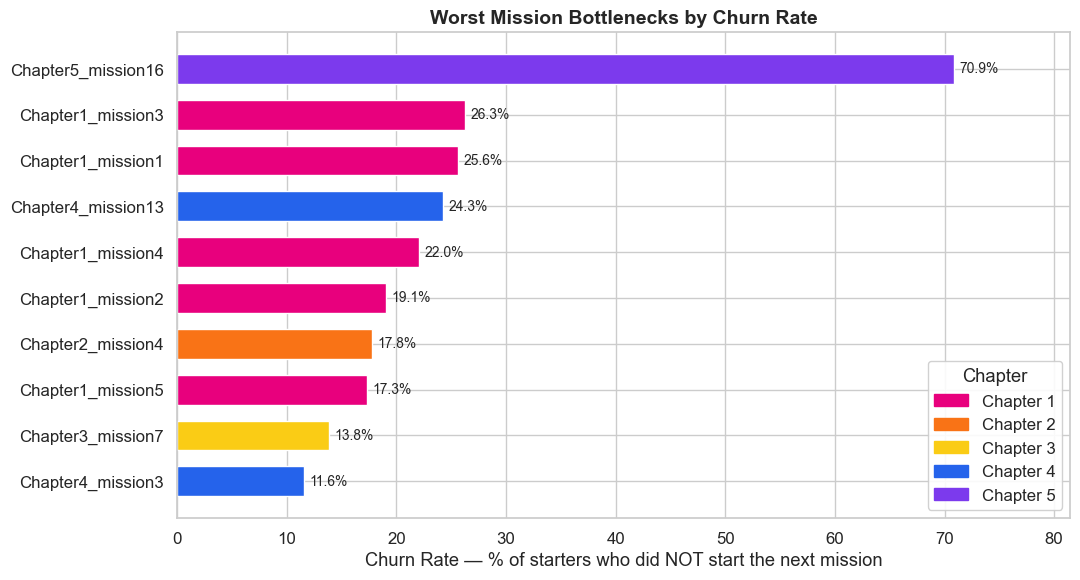

📊 Top 5 worst bottlenecks by churn rate:
      mission_name churn_pct  total_players_lost
Chapter5_mission16     70.9%             30751.0
 Chapter1_mission3     26.3%            263120.0
 Chapter1_mission1     25.6%            426443.0
Chapter4_mission13     24.3%             23069.0
 Chapter1_mission4     22.0%            162863.0


In [5]:
# ── Worst bottlenecks by churn RATE (% of starters who leave) ─────
# High churn rate = a mission is a "wall" regardless of how many players reach it
worst_rate = churn_by_mission.sort_values("weighted_churn_rate", ascending=False)

top10_rate  = worst_rate.head(10).sort_values("weighted_churn_rate")
colors_rate = [CHAPTER_COLORS[r] for r in top10_rate["chapter_num"]]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10_rate["mission_name"], top10_rate["weighted_churn_rate"] * 100,
               color=colors_rate, edgecolor="white", height=0.65)
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}%", va="center", fontsize=10)

ax.set_xlabel("Churn Rate — % of starters who did NOT start the next mission")
ax.set_title("Worst Mission Bottlenecks by Churn Rate", fontsize=14, fontweight="bold")
ax.set_xlim(0, worst_rate["weighted_churn_rate"].max() * 100 * 1.15)
ax.legend(handles=legend_handles, loc="lower right", title="Chapter", framealpha=0.9)
plt.tight_layout()
plt.savefig("churn_top10_rate.png", dpi=150, bbox_inches="tight")
plt.show()

print("📊 Top 5 worst bottlenecks by churn rate:")
print(
    worst_rate[["mission_name", "weighted_churn_rate", "total_players_lost"]]
    .head(5)
    .assign(churn_pct=lambda d: (d["weighted_churn_rate"] * 100).round(1).astype(str) + "%")
    [["mission_name", "churn_pct", "total_players_lost"]]
    .to_string(index=False)
)

### ❓ Q1b — Does Churn Differ by Player Level?

We group players into **4 bands of 10 levels** and measure how churn rate varies per group across each chapter.

| Group | Player Levels | Interpretation |
|-------|--------------|----------------|
| Lvl 2–11  | Early-game players | Highest player count, still learning |
| Lvl 12–21 | Mid-level players | Familiar with the game |
| Lvl 22–31 | Advanced players | Experienced, selective |
| Lvl 32–41 | High-level players | Veterans, small group |

The **heatmap** below shows average churn rate (%) per level group × chapter — red = high churn, white = low churn.

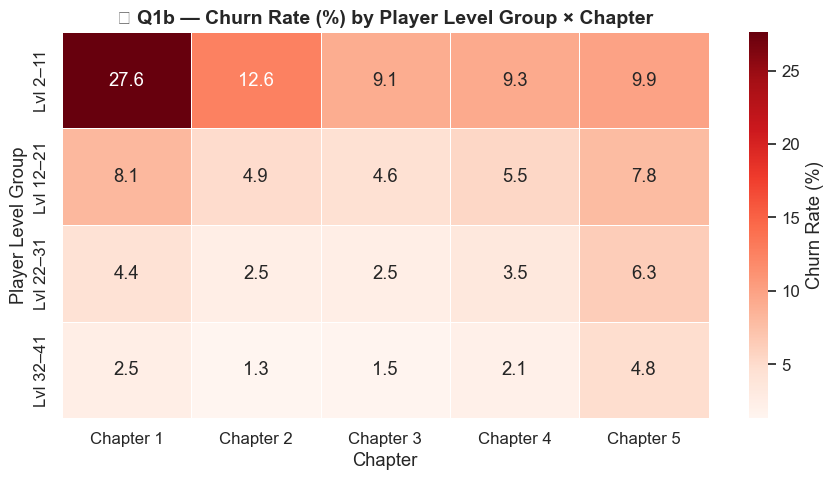


📊 Churn rate by level group and chapter:
            Chapter 1 Chapter 2 Chapter 3 Chapter 4 Chapter 5
level_group                                                  
Lvl 2–11        27.6%     12.6%      9.1%      9.3%      9.9%
Lvl 12–21        8.1%      4.9%      4.6%      5.5%      7.8%
Lvl 22–31        4.4%      2.5%      2.5%      3.5%      6.3%
Lvl 32–41        2.5%      1.3%      1.5%      2.1%      4.8%


In [6]:
# ── Aggregate: level group × chapter ─────────────────────────────
churn_by_lvlgrp_chapter = (
    df_s.dropna(subset=["churn_rate"])
        .groupby(["level_group", "lvl_grp_start", "chapter_num"], as_index=False)
        .agg(
            avg_churn_rate = ("churn_rate",    "mean"),
            total_lost     = ("churn_players", "sum"),
            total_starters = ("users_start",   "sum"),
        )
)
churn_by_lvlgrp_chapter["weighted_churn_rate"] = (
    churn_by_lvlgrp_chapter["total_lost"] / churn_by_lvlgrp_chapter["total_starters"]
)

# ── Pivot for heatmap: rows = level group, columns = chapter ──────
row_order = (
    churn_by_lvlgrp_chapter.drop_duplicates("level_group")
    .sort_values("lvl_grp_start")["level_group"].tolist()
)
heatmap_data = (
    churn_by_lvlgrp_chapter
    .pivot(index="level_group", columns="chapter_num", values="weighted_churn_rate")
    .reindex(row_order)
)
heatmap_data.columns = [f"Chapter {c}" for c in heatmap_data.columns]

# ── Heatmap chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    heatmap_data * 100,
    annot=True, fmt=".1f", cmap="Reds",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Churn Rate (%)"},
    ax=ax
)
ax.set_title(
    "❓ Q1b — Churn Rate (%) by Player Level Group × Chapter",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Chapter")
ax.set_ylabel("Player Level Group")
plt.tight_layout()
plt.savefig("churn_heatmap_levelgroup.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Churn rate by level group and chapter:")
print(heatmap_data.apply(lambda col: col.map(lambda x: f"{x*100:.1f}%")))

---
## 💰 Section 2 — Revenue Analysis

Revenue is generated when players pay **premium currency to skip missions**.

**Formula:** `Revenue ($) = skips × skip_cost × $0.0499`  
*(100 premium currency costs $4.99, so 1 currency = $0.0499)*

In [7]:
# ── Q2a: Total event revenue ──────────────────────────────────────
total_revenue     = df["revenue_usd"].sum()
total_skips       = int(df["users_skipped"].sum())
total_starts      = int(df["users_start"].sum())
overall_skip_rate = total_skips / total_starts

print("=" * 52)
print(f"  ❓ Q2a ANSWER")
print(f"  💵 Total event revenue  :  ${total_revenue:>12,.2f}")
print(f"  🎯 Total mission skips  :  {total_skips:>12,}")
print(f"  👥 Total mission starts :  {total_starts:>12,}")
print(f"  📊 Overall skip rate    :  {overall_skip_rate:>11.2%}")
print("=" * 52)

  ❓ Q2a ANSWER
  💵 Total event revenue  :  $  224,111.38
  🎯 Total mission skips  :       154,353
  👥 Total mission starts :    12,137,146
  📊 Overall skip rate    :        1.27%


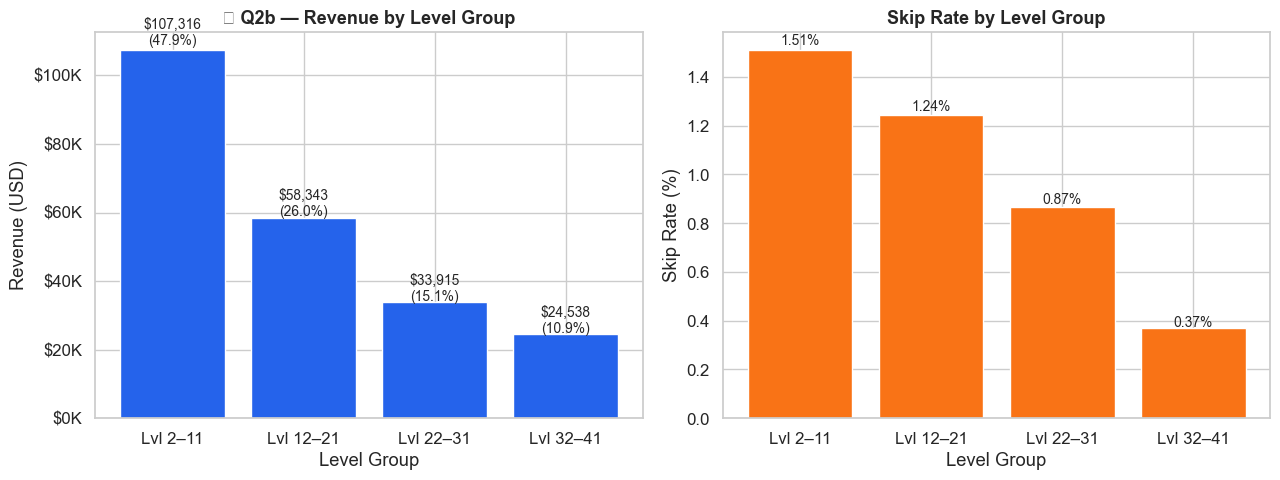

📊 Revenue breakdown by level group:
level_group revenue_usd revenue_pct skip_rate
   Lvl 2–11 $107,315.69       47.9%     1.51%
  Lvl 12–21  $58,343.33       26.0%     1.24%
  Lvl 22–31  $33,914.54       15.1%     0.87%
  Lvl 32–41  $24,537.83       10.9%     0.37%


In [8]:
# ── Q2b: Which level groups generated the most revenue? ───────────
rev_by_group = (
    df.groupby(["level_group", "lvl_grp_start"], as_index=False)
      .agg(
          revenue_usd    = ("revenue_usd",    "sum"),
          total_skips    = ("users_skipped",  "sum"),
          total_starters = ("users_start",    "sum"),
      )
      .sort_values("lvl_grp_start")
)
rev_by_group["revenue_pct"] = (
    rev_by_group["revenue_usd"] / rev_by_group["revenue_usd"].sum() * 100
)
rev_by_group["skip_rate"] = rev_by_group["total_skips"] / rev_by_group["total_starters"]

# ── Side-by-side: Revenue ($) and Skip Rate (%) by level group ────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Revenue
bars1 = axes[0].bar(
    rev_by_group["level_group"], rev_by_group["revenue_usd"],
    color=BLUE, edgecolor="white"
)
for bar, pct in zip(bars1, rev_by_group["revenue_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.015,
        f"${bar.get_height():,.0f}\n({pct:.1f}%)", ha="center", fontsize=10
    )
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K")
)
axes[0].set_title("❓ Q2b — Revenue by Level Group", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Level Group")
axes[0].set_ylabel("Revenue (USD)")

# Right: Skip rate
bars2 = axes[1].bar(
    rev_by_group["level_group"], rev_by_group["skip_rate"] * 100,
    color=ORANGE, edgecolor="white"
)
for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.015,
        f"{bar.get_height():.2f}%", ha="center", fontsize=10
    )
axes[1].set_title("Skip Rate by Level Group", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Level Group")
axes[1].set_ylabel("Skip Rate (%)")

plt.tight_layout()
plt.savefig("revenue_by_levelgroup.png", dpi=150, bbox_inches="tight")
plt.show()

print("📊 Revenue breakdown by level group:")
print(
    rev_by_group[["level_group", "revenue_usd", "revenue_pct", "skip_rate"]]
    .assign(
        revenue_usd  = lambda d: d["revenue_usd"].map("${:,.2f}".format),
        revenue_pct  = lambda d: d["revenue_pct"].map("{:.1f}%".format),
        skip_rate    = lambda d: (d["skip_rate"] * 100).map("{:.2f}%".format),
    )
    .to_string(index=False)
)

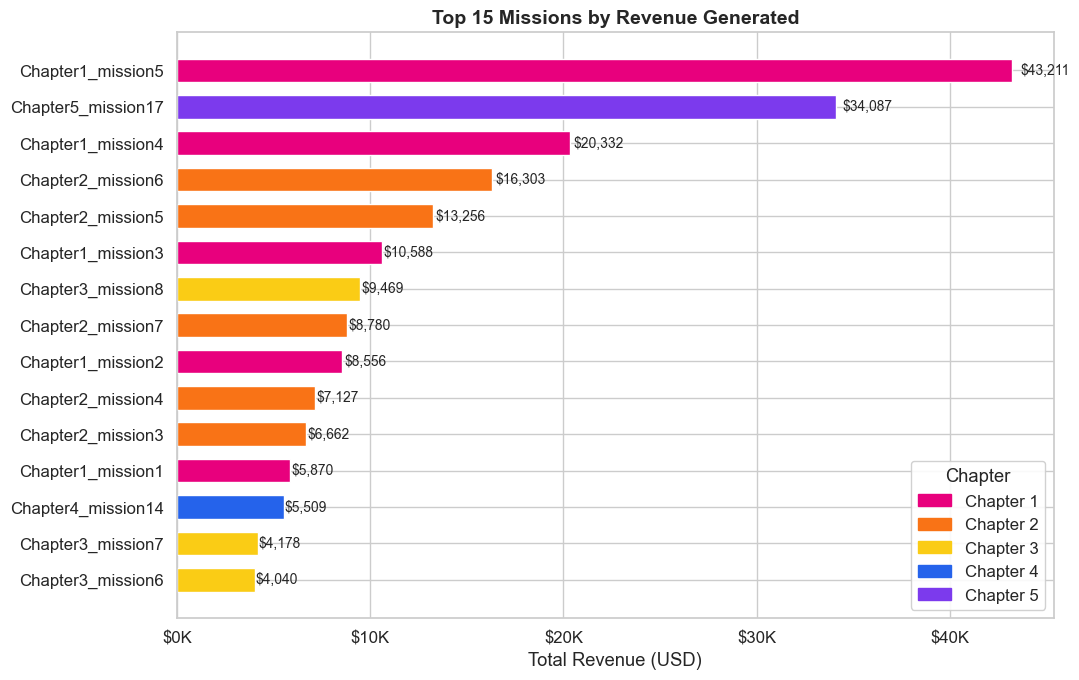

📊 Top 10 missions by revenue:
      mission_name revenue_usd  total_skips  avg_skip_cost
 Chapter1_mission5  $43,210.90        11546           75.0
Chapter5_mission17  $34,086.69          759          900.0
 Chapter1_mission4  $20,331.51        27163           15.0
 Chapter2_mission6  $16,303.08        21781           15.0
 Chapter2_mission5  $13,255.93        17710           15.0
 Chapter1_mission3  $10,587.53        14145           15.0
 Chapter3_mission8   $9,468.52         1265          150.0
 Chapter2_mission7   $8,779.91         1955           90.0
 Chapter1_mission2   $8,556.10        11431           15.0
 Chapter2_mission4   $7,127.22         9522           15.0

💡 Chapter 1 missions lead in revenue due to the highest player volume.
   Chapter 5 mission 17 (900-currency skip) stands out despite few players — high willingness to pay.


In [9]:
# ── Top missions by revenue ───────────────────────────────────────
rev_by_mission = (
    df.groupby(
        ["mission_name", "chapter_num", "mission_num", "mission_order"],
        as_index=False
    )
    .agg(
        revenue_usd   = ("revenue_usd",    "sum"),
        total_skips   = ("users_skipped",  "sum"),
        avg_skip_cost = ("skip_cost",      "mean"),
    )
    .sort_values("revenue_usd", ascending=False)
)

# ── Chart: Top 15 missions by revenue ────────────────────────────
top15 = rev_by_mission.head(15).sort_values("revenue_usd")
colors_rev = [CHAPTER_COLORS[r] for r in top15["chapter_num"]]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15["mission_name"], top15["revenue_usd"],
               color=colors_rev, edgecolor="white", height=0.65)
for bar in bars:
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():,.0f}", va="center", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.set_xlabel("Total Revenue (USD)")
ax.set_title("Top 15 Missions by Revenue Generated", fontsize=14, fontweight="bold")
ax.legend(handles=legend_handles, loc="lower right", title="Chapter", framealpha=0.9)
plt.tight_layout()
plt.savefig("revenue_top15_missions.png", dpi=150, bbox_inches="tight")
plt.show()

print("📊 Top 10 missions by revenue:")
print(
    rev_by_mission[["mission_name", "revenue_usd", "total_skips", "avg_skip_cost"]]
    .head(10)
    .assign(revenue_usd=lambda d: d["revenue_usd"].map("${:,.2f}".format))
    .to_string(index=False)
)
print(f"\n💡 Chapter 1 missions lead in revenue due to the highest player volume.")
print(f"   Chapter 5 mission 17 (900-currency skip) stands out despite few players — high willingness to pay.")

---
## 💡 Section 3 — Recommendations for Future Events

### Reduce Player Drop-Off

1. **Fix the Chapter 1 funnel** — Missions 1–4 cause the largest absolute losses (~426K, 262K, 236K, 163K players). These are the entry point of the event. Reducing difficulty or length here has the highest impact on overall participation.

2. **Investigate Chapter 5 Mission 16** (~71% churn rate) — Nearly all remaining players abandon right before the final mission. A milestone reward or a preview of the final reward at that point could recover a large portion of late-game drop-off.

3. **Add chapter-transition incentives** — Players drop off at the boundary between chapters (e.g., after Chapter 1 Mission 5). A completion bonus or animated reward screen can motivate continuing.

4. **High-level players (Lvl 32–41) show different churn patterns** — Check the heatmap. If specific chapters spike for veterans, consider tuning rewards or difficulty for that segment.

---

### Improve Revenue

5. **Chapter 1 Mission 5 (75-currency skip) is the #1 revenue driver** (~$43K) — This sweet spot of mid-price + high volume is powerful. Introduce similar mid-priced skip options earlier in the funnel before most players have churned.

6. **Chapter 5 Mission 17 (900-currency skip, ~$34K)** shows that late-game survivors have high willingness to pay. Expand high-value skip options to other late-event missions.

7. **Early-level players (Lvl 2–11) are the largest group by volume** — Even a tiny improvement in their skip rate generates significant revenue. Consider a discounted "first skip" offer targeted at this group.

8. **Smooth the skip cost curve** — Jumps from 15 → 75 → 90 → 135+ currency are uneven. A more gradual pricing curve could increase conversion across more missions.

---
## Section 4 — Expected Impact Quantification

Each recommendation below is modelled using **actual numbers from the data**.  
Where assumptions are required (e.g. a 10% retention improvement), these match the estimates stated in the recommendations exactly.

> All revenue estimates use the same formula as the rest of the analysis: `skips × cost × $0.0499`

In [10]:
# ══════════════════════════════════════════════════════════════════
# REC 1 — Fix the Chapter 1 Funnel
# Assumption: 10% retention improvement across Ch.1 missions 1–5
# ══════════════════════════════════════════════════════════════════

ch1_churn_total = churn_by_mission[
    churn_by_mission["chapter_num"] == 1
]["total_players_lost"].sum()

# 10% of those lost players now continue to Chapter 2, 10% is like an objective to achieve
rec1_extra_players = ch1_churn_total * 0.10

# Revenue those extra players would generate in Ch.2
# (using current Ch.2 revenue per player who enters Ch.2 as the rate)
ch2m1_total_starts  = df[df["mission_name"] == "Chapter2_mission1"]["users_start"].sum()
ch2_total_revenue   = df[df["chapter_num"] == 2]["revenue_usd"].sum()
rev_per_ch2_entrant = ch2_total_revenue / ch2m1_total_starts
rec1_extra_revenue  = rec1_extra_players * rev_per_ch2_entrant

print("REC 1 — Fix the Chapter 1 Funnel")
print(f"  Total Chapter 1 churn (M1–M5)  : {ch1_churn_total:>12,.0f} players lost")
print(f"  10% retention improvement       : +{rec1_extra_players:>11,.0f} more players reach Ch.2")
print(f"  Rev per Ch.2 entrant (current)  :  ${rev_per_ch2_entrant:>10.4f}")
print(f"  ➜  Estimated revenue uplift     : +${rec1_extra_revenue:>10,.2f}")
print()

# ══════════════════════════════════════════════════════════════════
# REC 2 — Rescue the Chapter 5 Cliff
# Assumption: recover 50% of players lost at Ch.5 Mission 16
# ══════════════════════════════════════════════════════════════════

ch5m16_lost = churn_by_mission[
    churn_by_mission["mission_name"] == "Chapter5_mission16"
]["total_players_lost"].values[0]

rec2_extra_completions = ch5m16_lost * 0.50 #Assumption here of 50%

# Those recovered players now reach Ch.5 M17 — apply current M17 skip rate
ch5m17_skip_rate   = df[df["mission_name"] == "Chapter5_mission17"]["skip_rate"].mean()
ch5m17_cost        = 900  # gems
rec2_extra_revenue = rec2_extra_completions * ch5m17_skip_rate * ch5m17_cost * USD_PER_CURRENCY

print("REC 2 — Rescue the Chapter 5 Cliff")
print(f"  Ch.5 M16 total players lost     : {ch5m16_lost:>12,.0f} players")
print(f"  50% recovery                    : +{rec2_extra_completions:>11,.0f} event completions")
print(f"  Ch.5 M17 current skip rate      : {ch5m17_skip_rate:>11.2%}")
print(f"  ➜  Estimated extra M17 revenue  : +${rec2_extra_revenue:>10,.2f}")
print()

# ══════════════════════════════════════════════════════════════════
# REC 3 — Replicate the Ch.1 M5 Sweet Spot in Chapter 2
# Assumption: introduce 75-gem skip on Ch.2 M1–M3 (highest traffic Ch.2 missions)
#             at 50% of the Ch.1 M5 benchmark skip rate (conservative)
# ══════════════════════════════════════════════════════════════════

ch1m5_skip_rate    = df[df["mission_name"] == "Chapter1_mission5"]["skip_rate"].mean()
ch2_top3_missions  = ["Chapter2_mission1", "Chapter2_mission2", "Chapter2_mission3"]
ch2_top3_starts    = df[df["mission_name"].isin(ch2_top3_missions)]["users_start"].sum()

new_skip_cost_gems  = 75
# 50% of Ch1M5 rate: conservative — Ch.2 has less urgency than Ch.1 for many players
estimated_new_skips = ch2_top3_starts * ch1m5_skip_rate * 0.50
rec3_extra_revenue  = estimated_new_skips * new_skip_cost_gems * USD_PER_CURRENCY

print("REC 3 — Replicate the Ch.1 M5 Sweet Spot")
print(f"  Ch.1 M5 benchmark skip rate     : {ch1m5_skip_rate:>11.2%}  (at 75 gems)")
print(f"  Top 3 Ch.2 missions total starts: {ch2_top3_starts:>12,.0f} players")
print(f"  Estimated new skips (×50% rate) : {estimated_new_skips:>12,.0f}")
print(f"  ➜  Estimated revenue uplift     : +${rec3_extra_revenue:>10,.2f}")
print()

# ══════════════════════════════════════════════════════════════════
# REC 4 — Target Lvl 2-11 with a First-Skip Offer
# Assumption: discounted 30-gem first-skip offer achieves +1% skip rate in this group
# ══════════════════════════════════════════════════════════════════

lvl2_11             = df[df["level_group"] == "Lvl 2–11"]
lvl2_11_starts      = lvl2_11["users_start"].sum()
lvl2_11_skip_rate   = lvl2_11["users_skipped"].sum() / lvl2_11_starts
lvl2_11_revenue     = lvl2_11["revenue_usd"].sum()
lvl2_11_rev_pct     = lvl2_11_revenue / df["revenue_usd"].sum() * 100

discount_price_gems = 30   # discounted first-skip offer
extra_skip_rate     = 0.01  # +1% of starters convert
rec4_extra_skips    = lvl2_11_starts * extra_skip_rate
rec4_extra_revenue  = rec4_extra_skips * discount_price_gems * USD_PER_CURRENCY

print("REC 4 — Target Lvl 2–11 with a First-Skip Offer")
print(f"  Lvl 2–11 total mission starts   : {lvl2_11_starts:>12,.0f}")
print(f"  Current skip rate               : {lvl2_11_skip_rate:>11.2%}")
print(f"  Current revenue contribution    : {lvl2_11_rev_pct:>10.1f}% of total")
print(f"  +1% skip rate, 30-gem offer     : +{rec4_extra_skips:>11,.0f} extra skips")
print(f"  ➜  Estimated revenue uplift     : +${rec4_extra_revenue:>10,.2f}")
print()

# ══════════════════════════════════════════════════════════════════
# TOTAL IMPACT SUMMARY
# ══════════════════════════════════════════════════════════════════
total_current  = df["revenue_usd"].sum()
total_uplift   = rec1_extra_revenue + rec2_extra_revenue + rec3_extra_revenue + rec4_extra_revenue

print("=" * 56)
print(f"  {'Current total revenue':<30} : ${total_current:>10,.2f}")
print(f"  {'Estimated total uplift':<30} : +${total_uplift:>9,.2f}")
print(f"  {'Projected new total':<30} : ${total_current + total_uplift:>10,.2f}")
print(f"  {'% improvement':<30} : +{total_uplift / total_current * 100:>9.1f}%")
print("=" * 56)

REC 1 — Fix the Chapter 1 Funnel
  Total Chapter 1 churn (M1–M5)  :    1,188,249 players lost
  10% retention improvement       : +    118,825 more players reach Ch.2
  Rev per Ch.2 entrant (current)  :  $    0.1245
  ➜  Estimated revenue uplift     : +$ 14,794.10

REC 2 — Rescue the Chapter 5 Cliff
  Ch.5 M16 total players lost     :       30,751 players
  50% recovery                    : +     15,376 event completions
  Ch.5 M17 current skip rate      :       4.89%
  ➜  Estimated extra M17 revenue  : +$ 33,768.45

REC 3 — Replicate the Ch.1 M5 Sweet Spot
  Ch.1 M5 benchmark skip rate     :       1.48%  (at 75 gems)
  Top 3 Ch.2 missions total starts:    1,373,169 players
  Estimated new skips (×50% rate) :       10,174
  ➜  Estimated revenue uplift     : +$ 38,075.97

REC 4 — Target Lvl 2–11 with a First-Skip Offer
  Lvl 2–11 total mission starts   :    6,546,122
  Current skip rate               :       1.51%
  Current revenue contribution    :       47.9% of total
  +1% skip rate,

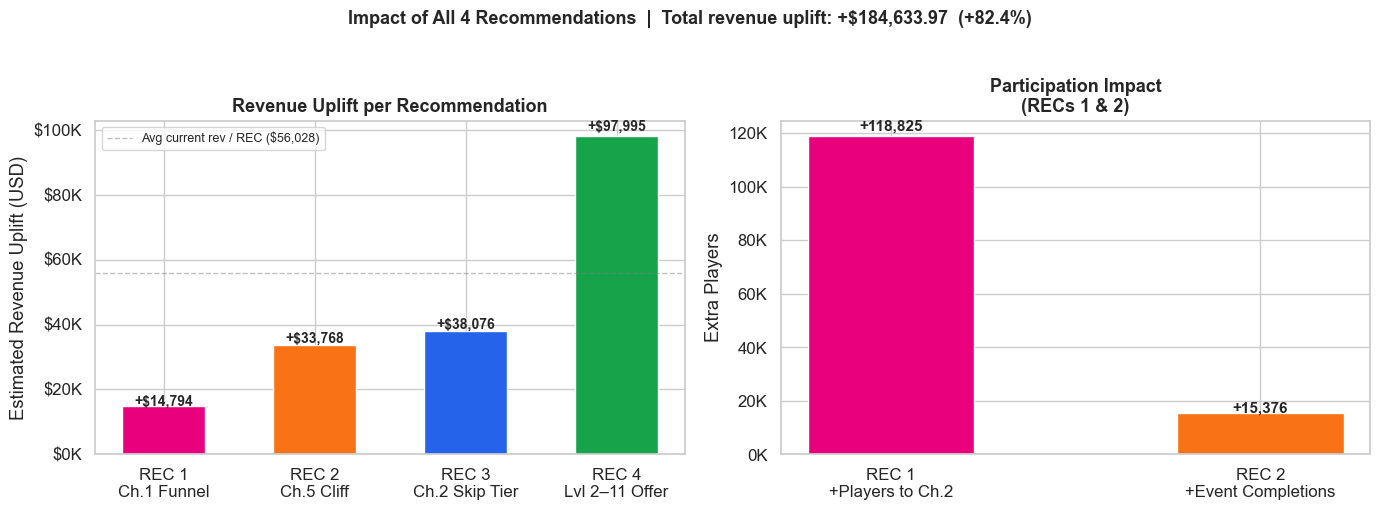

In [11]:
GREEN = "#16A34A"

recs         = ["REC 1\nCh.1 Funnel", "REC 2\nCh.5 Cliff", "REC 3\nCh.2 Skip Tier", "REC 4\nLvl 2–11 Offer"]
revenues     = [rec1_extra_revenue, rec2_extra_revenue, rec3_extra_revenue, rec4_extra_revenue]
participation = [rec1_extra_players, rec2_extra_completions, None, None]
bar_colors   = [PINK, ORANGE, BLUE, GREEN]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Revenue uplift per recommendation ───────────────────────
bars = axes[0].bar(recs, revenues, color=bar_colors, edgecolor="white", width=0.55)
for bar, val in zip(bars, revenues):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                 f"+${val:,.0f}", ha="center", fontsize=10, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0].set_ylabel("Estimated Revenue Uplift (USD)")
axes[0].set_title("Revenue Uplift per Recommendation", fontsize=13, fontweight="bold")

# Baseline reference line
axes[0].axhline(total_current / 4, color="gray", linewidth=1,
                linestyle="--", alpha=0.5, label=f"Avg current rev / REC (${total_current/4:,.0f})")
axes[0].legend(fontsize=9)

# ── Right: Participation impact (RECs 1 & 2 only) ────────────────
part_labels  = ["REC 1\n+Players to Ch.2", "REC 2\n+Event Completions"]
part_values  = [rec1_extra_players, rec2_extra_completions]
part_colors  = [PINK, ORANGE]

bars2 = axes[1].bar(part_labels, part_values, color=part_colors, edgecolor="white", width=0.45)
for bar, val in zip(bars2, part_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                 f"+{val:,.0f}", ha="center", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[1].set_ylabel("Extra Players")
axes[1].set_title("Participation Impact\n(RECs 1 & 2)", fontsize=13, fontweight="bold")

plt.suptitle(
    f"Impact of All 4 Recommendations  |  Total revenue uplift: +${total_uplift:,.2f}  (+{total_uplift/total_current*100:.1f}%)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("recommendations_impact.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ══════════════════════════════════════════════════════════════════
# POWER BI EXPORT — clean flat tables, snake_case columns, all numeric
# ══════════════════════════════════════════════════════════════════

out_path = "part1_powerbi_tables.xlsx"

# ── Table 1: fact_missions ─────────────────────────────────────────
# Main fact table — one row per (player_level × mission)
# Use this as the primary table in Power BI
fact_missions = df_s[[
    "player_level", "level_group",
    "mission_name", "chapter_num", "mission_num", "mission_order",
    "users_start", "users_skipped", "skip_cost",
    "revenue_usd", "skip_rate",
    "next_start", "churn_players", "churn_rate",
]].copy()

# ── Table 2: churn_by_mission ──────────────────────────────────────
# Aggregated churn per mission across all player levels
churn_summary = (
    churn_by_mission[[
        "mission_name", "chapter_num", "mission_num", "mission_order",
        "total_players_lost", "total_starters",
        "avg_churn_rate", "weighted_churn_rate",
    ]]
    .sort_values("mission_order")
    .reset_index(drop=True)
)

# ── Table 3: churn_by_levelgroup ───────────────────────────────────
# Churn per level group × chapter (used for the heatmap in Power BI)
churn_lvl = (
    churn_by_lvlgrp_chapter[[
        "level_group", "chapter_num",
        "avg_churn_rate", "weighted_churn_rate",
        "total_lost", "total_starters",
    ]]
    .sort_values(["level_group", "chapter_num"])
    .reset_index(drop=True)
)

# ── Table 4: revenue_by_levelgroup ────────────────────────────────
rev_lvl = (
    rev_by_group[[
        "level_group", "revenue_usd", "revenue_pct",
        "total_skips", "total_starters", "skip_rate",
    ]]
    .reset_index(drop=True)
)

# ── Table 5: revenue_by_mission ───────────────────────────────────
rev_mission = (
    rev_by_mission[[
        "mission_name", "chapter_num", "mission_num", "mission_order",
        "revenue_usd", "total_skips", "avg_skip_cost",
    ]]
    .sort_values("mission_order")
    .reset_index(drop=True)
)

# ── Write to Excel ────────────────────────────────────────────────
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    fact_missions.to_excel(writer,  index=False, sheet_name="fact_missions")
    churn_summary.to_excel(writer,  index=False, sheet_name="churn_by_mission")
    churn_lvl.to_excel(writer,      index=False, sheet_name="churn_by_levelgroup")
    rev_lvl.to_excel(writer,        index=False, sheet_name="revenue_by_levelgroup")
    rev_mission.to_excel(writer,    index=False, sheet_name="revenue_by_mission")

print(f"✅ Exported → '{out_path}'")
print()
print("📋 Sheets:")
print(f"   fact_missions         {len(fact_missions):>5,} rows  ← main Power BI table")
print(f"   churn_by_mission      {len(churn_summary):>5,} rows")
print(f"   churn_by_levelgroup   {len(churn_lvl):>5,} rows")
print(f"   revenue_by_levelgroup {len(rev_lvl):>5,} rows")
print(f"   revenue_by_mission    {len(rev_mission):>5,} rows")

✅ Exported → 'part1_powerbi_tables.xlsx'

📋 Sheets:
   fact_missions         2,040 rows  ← main Power BI table
   churn_by_mission         50 rows
   churn_by_levelgroup      20 rows
   revenue_by_levelgroup     4 rows
   revenue_by_mission       51 rows


---
# 🧪 Part 2 — A/B Test Analysis

---

## 📖 Metric Definitions

| Metric | Full Name | What it measures |
|--------|-----------|-----------------|
| **ARPDAU** | Average Revenue Per **Daily Active User** | Total revenue ÷ all daily active users *(payers + non-payers)*. The primary monetization health metric — reflects how much revenue the game generates per player per day, regardless of whether they spent or not. |
| **ARPPU** | Average Revenue Per **Paying User** | Total revenue ÷ paying users only. Measures how much each payer spends on average. A high ARPPU means few users pay but they pay a lot; a low ARPPU means more users pay but less each. |

---

## Test Setup

We just completed an A/B test on a monetization-driving feature with the following results:

| Metric | Group A — Control | Group B — Treatment |
|--------|:-----------------:|:-------------------:|
| ARPDAU | $0.15 | $0.16 |
| ARPPU  | $30   | $16   |

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Raw test results ───────────────────────────────────────────────
ab = pd.DataFrame({
    "group":  ["Group A (Control)", "Group B (Treatment)"],
    "arpdau": [0.15,  0.16],
    "arppu":  [30.00, 16.00],
})

# ── % changes vs Group A (control) ────────────────────────────────
ab["arpdau_delta_pct"] = (ab["arpdau"] / ab["arpdau"].iloc[0] - 1) * 100
ab["arppu_delta_pct"]  = (ab["arppu"]  / ab["arppu"].iloc[0]  - 1) * 100

# ── Summary ───────────────────────────────────────────────────────
print("=" * 58)
print(f"  {'Metric':<24} {'Group A':>9} {'Group B':>9} {'Δ vs A':>9}")
print("-" * 58)
print(f"  {'ARPDAU ($)':<24} {ab.loc[0,'arpdau']:>9.2f} {ab.loc[1,'arpdau']:>9.2f} {ab.loc[1,'arpdau_delta_pct']:>+8.1f}%")
print(f"  {'ARPPU ($)':<24} {ab.loc[0,'arppu']:>9.2f} {ab.loc[1,'arppu']:>9.2f} {ab.loc[1,'arppu_delta_pct']:>+8.1f}%")
print("=" * 58)

  Metric                     Group A   Group B    Δ vs A
----------------------------------------------------------
  ARPDAU ($)                    0.15      0.16     +6.7%
  ARPPU ($)                    30.00     16.00    -46.7%


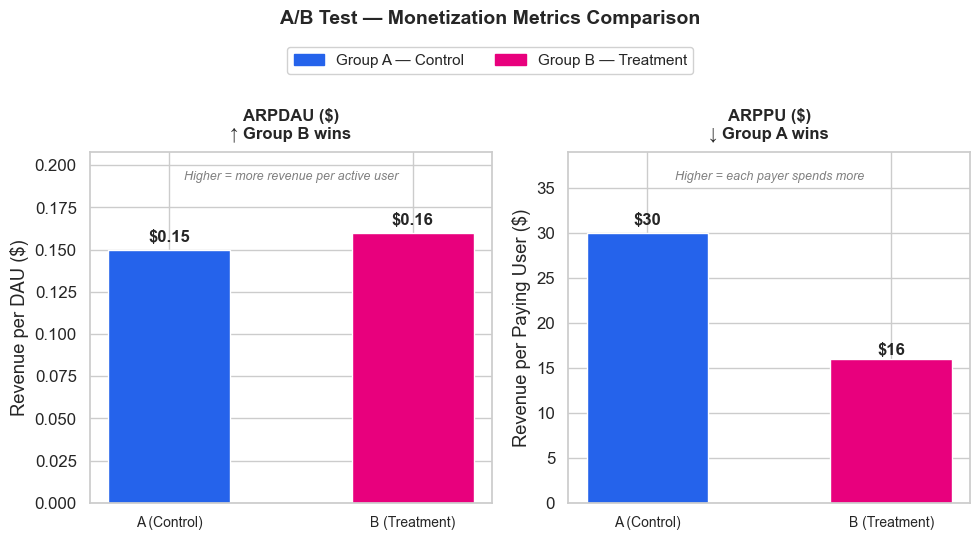

In [14]:
GROUP_A_COLOR = "#2563EB"   # blue  = control
GROUP_B_COLOR = "#E8007D"   # pink  = treatment

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

def annotated_bar(ax, values, labels, title, fmt, ylabel, note=None):
    colors = [GROUP_A_COLOR, GROUP_B_COLOR]
    bars = ax.bar([0, 1], values, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.03,
                fmt(val), ha="center", fontsize=12, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.3)
    if note:
        ax.annotate(note, xy=(0.5, 0.92), xycoords="axes fraction",
                    ha="center", fontsize=9, color="gray", style="italic")

short_labels = ["A (Control)", "B (Treatment)"]

annotated_bar(axes[0],
    ab["arpdau"].tolist(), short_labels,
    "ARPDAU ($)\n↑ Group B wins",
    lambda v: f"${v:.2f}", "Revenue per DAU ($)",
    note="Higher = more revenue per active user")

annotated_bar(axes[1],
    ab["arppu"].tolist(), short_labels,
    "ARPPU ($)\n↓ Group A wins",
    lambda v: f"${v:.0f}", "Revenue per Paying User ($)",
    note="Higher = each payer spends more")

legend_patches = [
    mpatches.Patch(color=GROUP_A_COLOR, label="Group A — Control"),
    mpatches.Patch(color=GROUP_B_COLOR, label="Group B — Treatment"),
]
fig.legend(handles=legend_patches, loc="upper center", ncol=2,
           fontsize=11, framealpha=0.9, bbox_to_anchor=(0.5, 1.02))
plt.suptitle("A/B Test — Monetization Metrics Comparison", fontsize=14,
             fontweight="bold", y=1.08)
plt.tight_layout()
plt.savefig("ab_test_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## ❓ Q1 — Which scenario would I pick as winner?

**→ Group B, provisionally.**

Group B has a higher ARPDAU ($0.16 vs $0.15, +6.7%), which is the stronger business signal. ARPDAU captures the monetization health of the entire player base — including non-payers — making it the most relevant KPI when the goal is overall revenue performance.

However, this is a directional conclusion only. To confirm it, I would request:

| Missing data | Why it matters |
|---|---|
| Sample size | Need to check if the +6.7% ARPDAU difference is statistically significant |
| Test duration | Short tests can overfit to novelty effects |
| Retention impact | If Group B's feature causes players to quit faster, revenue gains won't hold |
| Revenue distribution | Check if Group B's revenue comes from many small purchases or a few large ones |

> **The case for Group A:** Its ARPPU ($30 vs $16, -46.7%) shows that its payers spend far more per transaction. If the business strategy is to deepen engagement with high-value "whale" spenders, Group A may be the better long-term choice.

---
## ❓ Q2 — Why are ARPDAU and ARPPU behaving differently?

The two metrics measure different things, so they can move in opposite directions depending on *how* revenue is generated.

- **ARPDAU** ($0.15 → $0.16, +6.7%) measures revenue spread across **all** active users — payers and non-payers alike.
- **ARPPU** ($30 → $16, -46.7%) measures revenue per **paying user only**.

The most likely explanation is that **Group B's feature attracted more players into spending, but at lower amounts per transaction.**

- If more players make smaller purchases, total revenue per active user can go up (ARPDAU ↑)
- But if those new purchases are smaller than what existing payers were spending, the average per paying user goes down (ARPPU ↓)

**In short:** Group A has fewer, bigger spenders. Group B likely has more, smaller spenders. The overall revenue per active user is slightly higher in Group B because the increase in the number of payers more than compensates for the lower individual spend.

> Without the actual number of paying users in each group, we cannot confirm this interpretation — but the directional signal is consistent with a feature that lowered the barrier to spending.

---
## ❓ Q3 — What feature could have been tested?

Given that the results show **more payers spending less each**, the tested feature was most likely something that **lowered the entry price or made purchasing feel more accessible**.

Most probable candidates:

| Feature | Why it fits |
|---|---|
| **Starter pack / first-purchase offer** | A discounted bundle (e.g. $1.99 instead of $9.99) specifically for new payers — classic conversion driver |
| **New lower-cost currency pack** | Adding a $0.99 or $1.99 option broadens the audience who will spend at all |
| **Mission skip discount or sale event** | Temporary reduced skip costs drive impulse purchases at lower amounts |
| **Reduced-price bundle in the shop** | A value bundle at ~$5–10 instead of $30 attracts more buyers but lowers avg spend |
| **Revamped shop UI / offer placement** | Making purchase prompts more visible and contextual can increase conversion without necessarily raising spend per transaction |

> **Most likely:** A **low-cost entry-level offer** (starter pack or discounted currency bundle) introduced for Group B. This is the textbook mechanism for increasing payer conversion while decreasing ARPPU — it has been validated across many mobile games as an effective tool to grow the payer base.

---
## ✅ Final Conclusion

| | Group A | Group B | Verdict |
|---|---|---|---|
| ARPDAU | $0.15 | **$0.16** | Group B ↑ |
| ARPPU | **$30** | $16 | Group A ↑ |
| **Recommended winner** | | **Group B** | *(pending significance check)* |

**Group B is the provisional winner** because it generates more revenue per active user overall — the metric that matters most for the health of a live game.

The divergence between ARPDAU and ARPPU is not a contradiction — it is the expected outcome of a feature that lowers the spending barrier and brings in more players at a lower price point.

**Before shipping Group B to 100% of players, confirm:**
1. Statistical significance of the ARPDAU difference
2. No negative impact on Day 7 / Day 30 retention
3. Revenue trend over the full test window (not just averages)